In [3]:
!pip install grad-cam shap lime torch torchvision scikit-image scipy pandas scikit-learn seaborn matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 82.3 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from skimage.transform import resize
from skimage.metrics import structural_similarity as ssim
from scipy.stats import pearsonr
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
    classification_report, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

NUM_CLASSES = 5
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

Device: cuda


In [5]:
class APTOSDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = f"{self.img_dir}/{row['id_code']}.png"
        image = Image.open(img_path).convert("RGB")
        label = int(row['diagnosis'])
        if self.transform:
            image = self.transform(image)
        return image, label


BASE_PATH = "/kaggle/input/datasets/mariaherrerot/aptos2019"

train_csv_path = f"{BASE_PATH}/train_1.csv"
valid_csv_path = f"{BASE_PATH}/valid.csv"
train_img_dir = f"{BASE_PATH}/train_images/train_images"
valid_img_dir = f"{BASE_PATH}/val_images/val_images"

train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(valid_csv_path)

print("Train size:", len(train_df), "Val size:", len(val_df))
print("Train class distribution:\n", train_df['diagnosis'].value_counts().sort_index())

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = APTOSDataset(train_df, train_img_dir, transform=transform)
test_dataset = APTOSDataset(val_df, valid_img_dir, transform=transform)

Train size: 2930 Val size: 366
Train class distribution:
 diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64


In [6]:
train_labels_array = train_df['diagnosis'].values
class_counts = np.bincount(train_labels_array, minlength=NUM_CLASSES)
print("Class counts:", class_counts)

class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights (for loss):", class_weights_tensor)

sample_weights = [class_weights[label] for label in train_labels_array]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

sample_images, sample_labels = next(iter(train_loader))
print("Sanity check — batch shape:", sample_images.shape)
print("Sampled batch label distribution:", np.bincount(sample_labels.numpy(), minlength=NUM_CLASSES))

Class counts: [1434  300  808  154  234]
Class weights (for loss): tensor([0.2174, 1.0394, 0.3859, 2.0248, 1.3325], device='cuda:0')
Sanity check — batch shape: torch.Size([32, 3, 224, 224])
Sampled batch label distribution: [ 6 12  3  6  5]


In [7]:
def build_model(name):
    if name == "resnet18":
        m = models.resnet18(weights="IMAGENET1K_V1")
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
        target_layer = [m.layer4[-1]]
    elif name == "densenet121":
        m = models.densenet121(weights="IMAGENET1K_V1")
        m.classifier = nn.Linear(m.classifier.in_features, NUM_CLASSES)
        target_layer = [m.features[-1]]
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights="IMAGENET1K_V1")
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, NUM_CLASSES)
        target_layer = [m.features[-1]]
    else:
        raise ValueError(f"Unknown model name: {name}")
    return m.to(device), target_layer

In [8]:
def train_and_evaluate(model, model_name, max_epochs=5, early_stop_patience=3):
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    best_val_acc = 0.0  
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_loss = running_loss / len(train_loader)
        history["train_loss"].append(train_loss)

        model.eval()
        val_loss = 0.0
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                probs = torch.softmax(outputs, dim=1)
                preds = torch.argmax(probs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        val_loss /= len(test_loader)
        val_acc = accuracy_score(all_labels, all_preds)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)  # Scheduler still monitors val_loss (standard practice)
        print(f"[{model_name}] Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:  
            best_val_acc = val_acc  
            patience_counter = 0
            torch.save(model.state_dict(), f"/kaggle/working/{model_name}_best.pth")
            print("  -> Best model saved")
        else:
            patience_counter += 1
            print(f"  -> No improvement ({patience_counter}/{early_stop_patience})")
            if patience_counter >= early_stop_patience:
                print("  -> Early stopping triggered")
                break

    model.load_state_dict(torch.load(f"/kaggle/working/{model_name}_best.pth"))
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0
    )
    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
    report = classification_report(all_labels, all_preds, labels=list(range(NUM_CLASSES)),
                                     target_names=CLASS_NAMES, zero_division=0)

    all_probs_arr = np.array(all_probs)
    try:
        roc_auc = roc_auc_score(all_labels, all_probs_arr, multi_class='ovr',
                                  labels=list(range(NUM_CLASSES)))
    except Exception as e:
        print(f"  ROC-AUC could not be computed (likely a missing class in val set): {e}")
        roc_auc = None

    metrics = {
        "model": model_name, "accuracy": acc, "precision": precision,
        "recall": recall, "f1": f1, "roc_auc": roc_auc
    }
    return model, history, metrics, cm, report


model_names = ["resnet18", "densenet121", "efficientnet_b0"]
models_dict = {}
target_layers_dict = {}
histories_dict = {}
metrics_list = []
confusion_matrices = {}
reports = {}

for name in model_names:
    print(f"\n{'='*50}\nTraining {name}\n{'='*50}")
    m, target_layer = build_model(name)
    m, history, metrics, cm, report = train_and_evaluate(m, name)

    models_dict[name] = m
    target_layers_dict[name] = target_layer
    histories_dict[name] = history
    metrics_list.append(metrics)
    confusion_matrices[name] = cm
    reports[name] = report

    print(f"\n{name} Classification Report:\n{report}")

metrics_df = pd.DataFrame(metrics_list)
metrics_df.to_csv("/kaggle/working/model_metrics.csv", index=False)
print("\nFinal model comparison:\n", metrics_df)


Training resnet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


[resnet18] Epoch 1: train_loss=0.6197, val_loss=0.8408, val_acc=0.6940
  -> Best model saved
[resnet18] Epoch 2: train_loss=0.2209, val_loss=0.9477, val_acc=0.7295
  -> Best model saved
[resnet18] Epoch 3: train_loss=0.1311, val_loss=0.9791, val_acc=0.7623
  -> Best model saved
[resnet18] Epoch 4: train_loss=0.0856, val_loss=0.8987, val_acc=0.8060
  -> Best model saved
[resnet18] Epoch 5: train_loss=0.0528, val_loss=1.0613, val_acc=0.8279
  -> Best model saved

resnet18 Classification Report:
                  precision    recall  f1-score   support

           No DR       0.96      0.99      0.97       172
            Mild       0.69      0.72      0.71        40
        Moderate       0.75      0.75      0.75       104
          Severe       0.53      0.41      0.46        22
Proliferative DR       0.65      0.61      0.63        28

        accuracy                           0.83       366
       macro avg       0.72      0.70      0.70       366
    weighted avg       0.82      0.8

100%|██████████| 30.8M/30.8M [00:00<00:00, 202MB/s]


[densenet121] Epoch 1: train_loss=0.7172, val_loss=0.9529, val_acc=0.6913
  -> Best model saved
[densenet121] Epoch 2: train_loss=0.2778, val_loss=0.8790, val_acc=0.7514
  -> Best model saved
[densenet121] Epoch 3: train_loss=0.1562, val_loss=0.9445, val_acc=0.7923
  -> Best model saved
[densenet121] Epoch 4: train_loss=0.1015, val_loss=0.9098, val_acc=0.8169
  -> Best model saved
[densenet121] Epoch 5: train_loss=0.0893, val_loss=1.0463, val_acc=0.8087
  -> No improvement (1/3)

densenet121 Classification Report:
                  precision    recall  f1-score   support

           No DR       0.98      0.96      0.97       172
            Mild       0.57      0.72      0.64        40
        Moderate       0.77      0.76      0.77       104
          Severe       0.53      0.41      0.46        22
Proliferative DR       0.61      0.61      0.61        28

        accuracy                           0.82       366
       macro avg       0.69      0.69      0.69       366
    weighted a

100%|██████████| 20.5M/20.5M [00:00<00:00, 205MB/s]


[efficientnet_b0] Epoch 1: train_loss=1.0438, val_loss=1.1825, val_acc=0.5464
  -> Best model saved
[efficientnet_b0] Epoch 2: train_loss=0.5580, val_loss=1.0333, val_acc=0.6011
  -> Best model saved
[efficientnet_b0] Epoch 3: train_loss=0.3643, val_loss=1.0037, val_acc=0.6858
  -> Best model saved
[efficientnet_b0] Epoch 4: train_loss=0.2670, val_loss=0.9657, val_acc=0.7377
  -> Best model saved
[efficientnet_b0] Epoch 5: train_loss=0.2077, val_loss=0.9913, val_acc=0.7732
  -> Best model saved

efficientnet_b0 Classification Report:
                  precision    recall  f1-score   support

           No DR       0.99      0.97      0.98       172
            Mild       0.53      0.85      0.65        40
        Moderate       0.78      0.54      0.64       104
          Severe       0.38      0.50      0.43        22
Proliferative DR       0.47      0.54      0.50        28

        accuracy                           0.77       366
       macro avg       0.63      0.68      0.64     

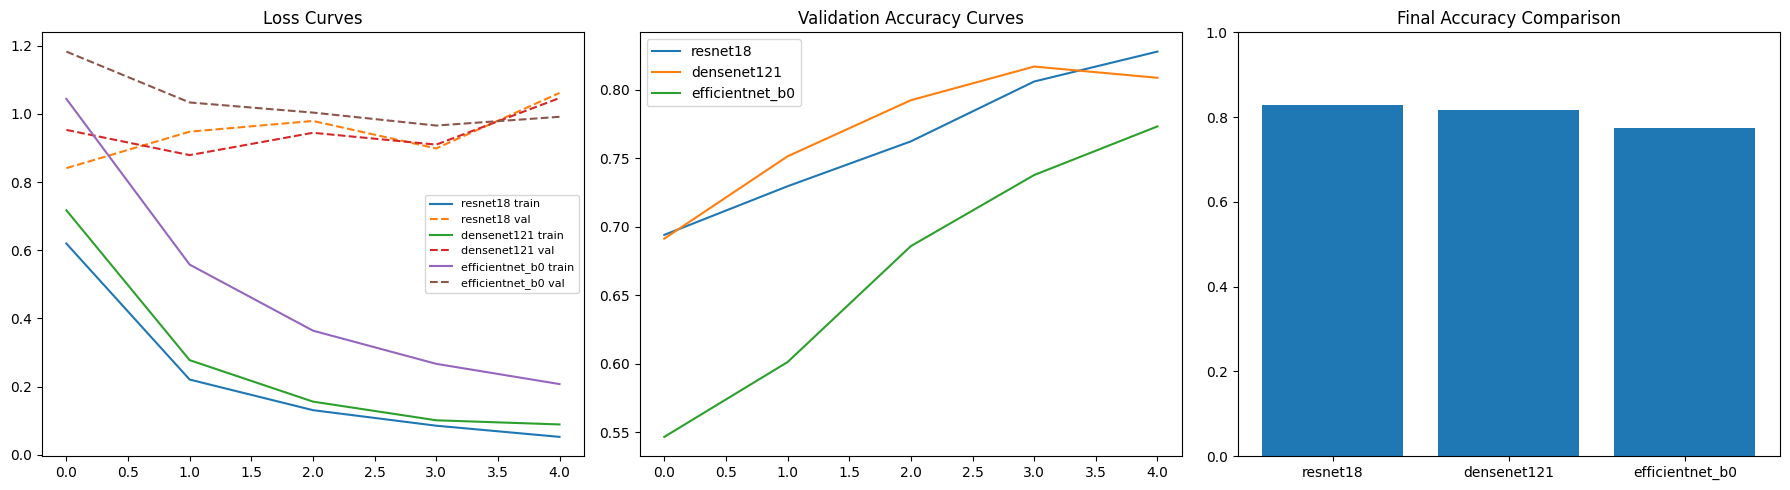

Saved training_curves_comparison.png


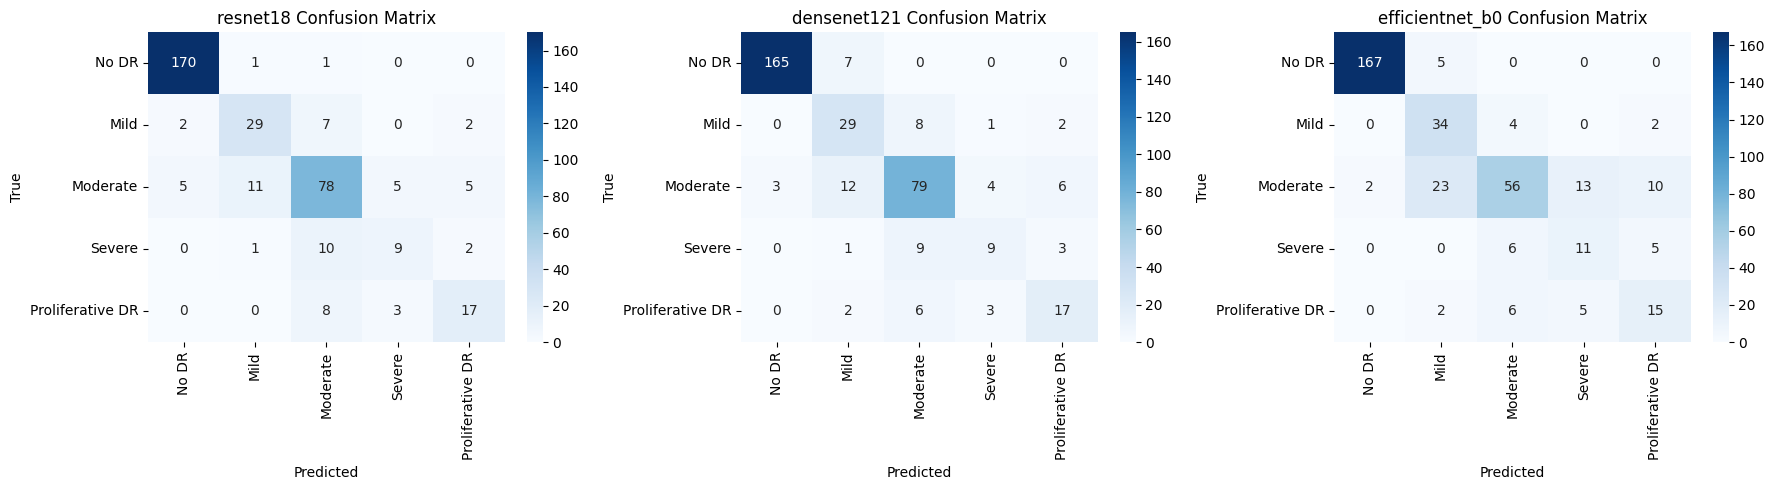

Saved confusion_matrices.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for name in model_names:
    axes[0].plot(histories_dict[name]["train_loss"], label=f"{name} train")
    axes[0].plot(histories_dict[name]["val_loss"], label=f"{name} val", linestyle='--')
axes[0].set_title("Loss Curves")
axes[0].legend(fontsize=8)

for name in model_names:
    axes[1].plot(histories_dict[name]["val_acc"], label=name)
axes[1].set_title("Validation Accuracy Curves")
axes[1].legend()

axes[2].bar(metrics_df["model"], metrics_df["accuracy"])
axes[2].set_title("Final Accuracy Comparison")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_comparison.png")
plt.show()   # <-- YEH LINE ADD HUI, ab notebook mein dikhega
print("Saved training_curves_comparison.png")


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, name in enumerate(model_names):
    sns.heatmap(confusion_matrices[name], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[i])
    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices.png")
plt.show()   # <-- YEH LINE ADD HUI, ab notebook mein dikhega
print("Saved confusion_matrices.png")

In [10]:
from pytorch_grad_cam import GradCAM
import shap
from lime import lime_image


def get_gradcam_map(model, target_layer, image_tensor):
    cam = GradCAM(model=model, target_layers=target_layer)
    input_batch = image_tensor.unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=input_batch)[0, :]
    return grayscale_cam


def get_shap_map(model, background, image_tensor, target_class):
    explainer = shap.GradientExplainer(model, background.to(device))
    input_batch = image_tensor.unsqueeze(0).to(device)
    shap_values = explainer.shap_values(input_batch)
    shap_map_for_class = shap_values[0, :, :, :, target_class]
    shap_map_2d = shap_map_for_class.sum(axis=0)
    shap_map_normalized = (shap_map_2d - shap_map_2d.min()) / (shap_map_2d.max() - shap_map_2d.min() + 1e-8)
    return shap_map_normalized


def get_lime_map(model, image_tensor):
    def predict_fn(images_np_list):
        model.eval()
        batch = torch.stack([
            torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32) for img in images_np_list
        ]).to(device)
        with torch.no_grad():
            outputs = model(batch)
            probs = F.softmax(outputs, dim=1)
        return probs.cpu().numpy()

    img_np = image_tensor.permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

    explainer_lime = lime_image.LimeImageExplainer()
    explanation = explainer_lime.explain_instance(
        img_np, predict_fn, top_labels=NUM_CLASSES, hide_color=0, num_samples=100
    )
    _, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
    )
    return mask.astype(float)

Using 20 test images for XAI evaluation


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Finished explanations for efficientnet_b0


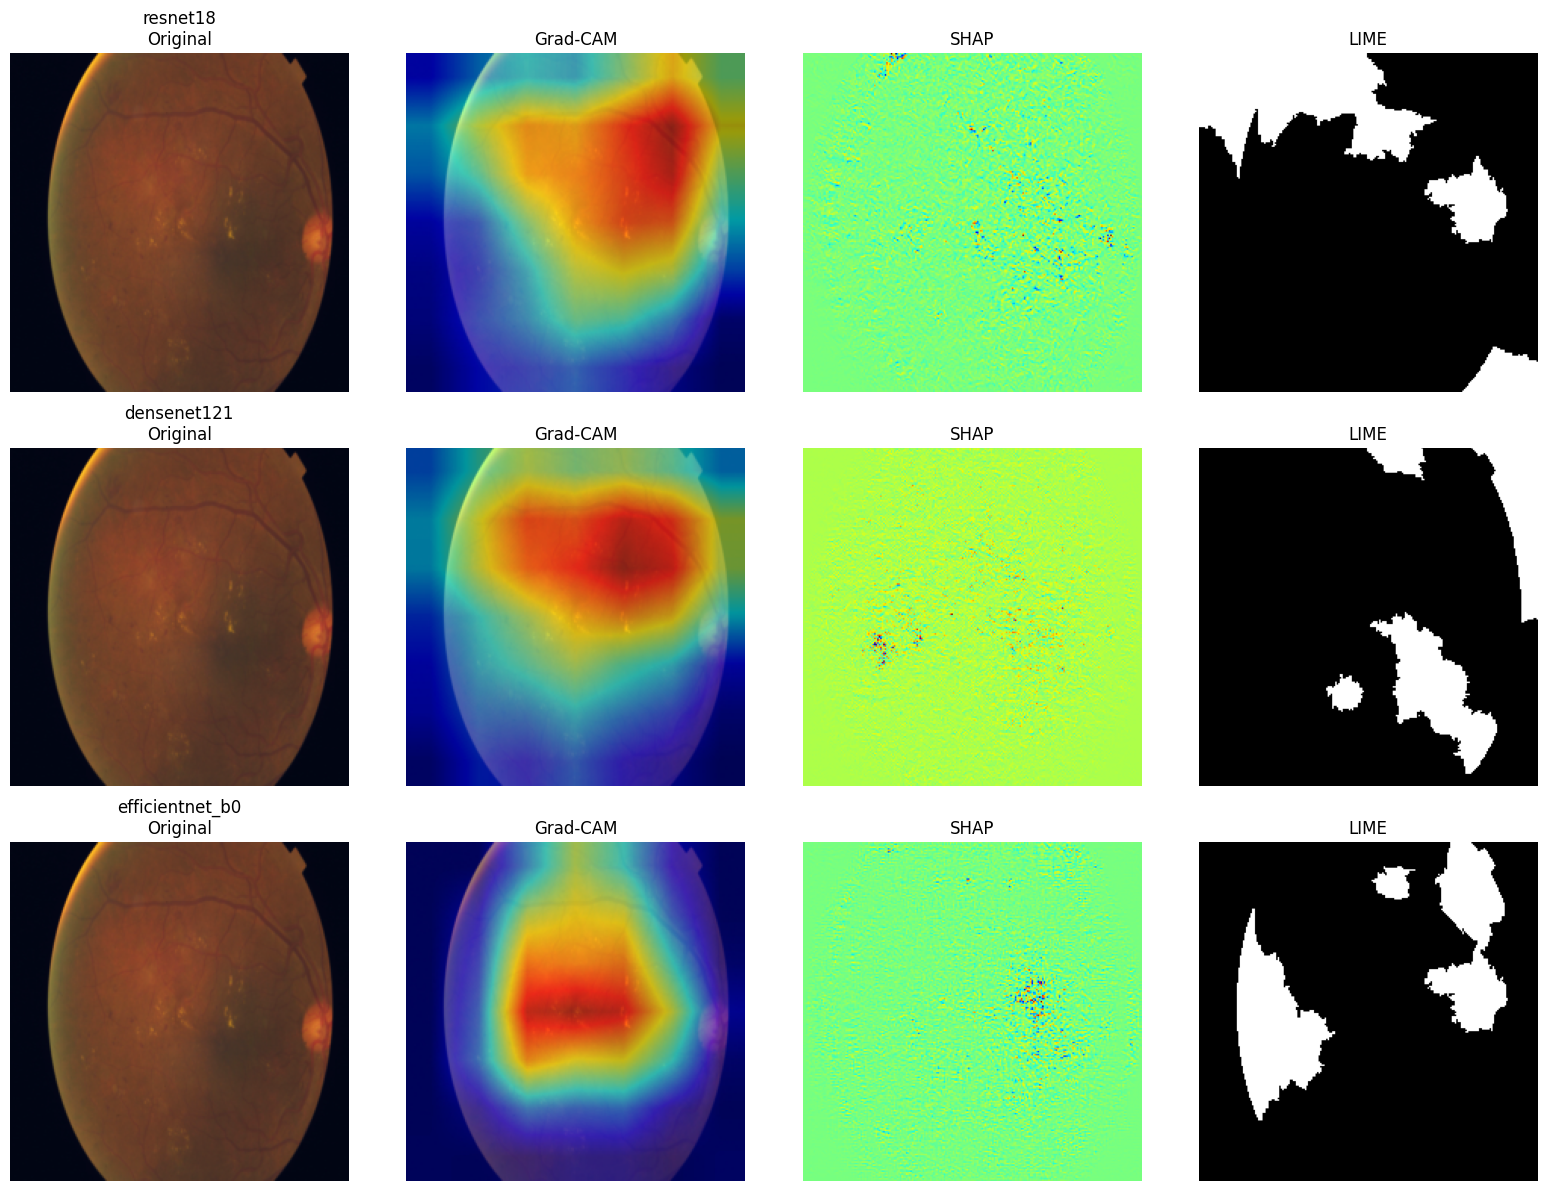

Saved explanation_examples.png


In [11]:
NUM_TEST_IMAGES = 20

all_test_images_list = []
all_test_labels_list = []
for images, labels in test_loader:
    all_test_images_list.append(images)
    all_test_labels_list.append(labels)
    if sum(t.shape[0] for t in all_test_images_list) >= NUM_TEST_IMAGES:
        break

all_test_images = torch.cat(all_test_images_list)[:NUM_TEST_IMAGES]
all_test_labels = torch.cat(all_test_labels_list)[:NUM_TEST_IMAGES]
print(f"Using {len(all_test_images)} test images for XAI evaluation")

explanation_maps = {name: {} for name in model_names}

for model_name in model_names:
    model = models_dict[model_name]
    target_layer = target_layers_dict[model_name]
    background = all_test_images[:10]

    for img_idx in range(len(all_test_images)):
        image_tensor = all_test_images[img_idx]
        target_class = all_test_labels[img_idx].item()

        gradcam_map = get_gradcam_map(model, target_layer, image_tensor)
        shap_map = get_shap_map(model, background, image_tensor, target_class)
        lime_map = get_lime_map(model, image_tensor)

        explanation_maps[model_name][img_idx] = {
            "gradcam": gradcam_map, "shap": shap_map, "lime": lime_map
        }

    print(f"Finished explanations for {model_name}")

from pytorch_grad_cam.utils.image import show_cam_on_image

fig, axes = plt.subplots(len(model_names), 4, figsize=(16, 4 * len(model_names)))
for i, model_name in enumerate(model_names):
    example_idx = 0
    img_tensor = all_test_images[example_idx]
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

    maps = explanation_maps[model_name][example_idx]
    gradcam_vis = show_cam_on_image(img_np, resize(maps["gradcam"], (224, 224)), use_rgb=True)

    axes[i, 0].imshow(img_np); axes[i, 0].set_title(f"{model_name}\nOriginal"); axes[i, 0].axis("off")
    axes[i, 1].imshow(gradcam_vis); axes[i, 1].set_title("Grad-CAM"); axes[i, 1].axis("off")
    axes[i, 2].imshow(resize(maps["shap"], (224, 224)), cmap="jet"); axes[i, 2].set_title("SHAP"); axes[i, 2].axis("off")
    axes[i, 3].imshow(resize(maps["lime"], (224, 224)), cmap="gray"); axes[i, 3].set_title("LIME"); axes[i, 3].axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/explanation_examples.png")
plt.show()
print("Saved explanation_examples.png")

                                       iou      dice   pearson      ssim
model           pair                                                    
densenet121     Grad-CAM vs LIME  0.117134  0.206736 -0.028549  0.065243
                Grad-CAM vs SHAP  0.270104  0.404265  0.001686  0.410217
                SHAP vs LIME      0.110945  0.194086  0.000027  0.059387
efficientnet_b0 Grad-CAM vs LIME  0.113842  0.190461  0.026280  0.123056
                Grad-CAM vs SHAP  0.155677  0.254847  0.001460  0.272175
                SHAP vs LIME      0.096032  0.166617 -0.000668  0.056694
resnet18        Grad-CAM vs LIME  0.098636  0.173359 -0.037144  0.079181
                Grad-CAM vs SHAP  0.203170  0.325177  0.002788  0.352991
                SHAP vs LIME      0.120992  0.209302  0.000060  0.056245


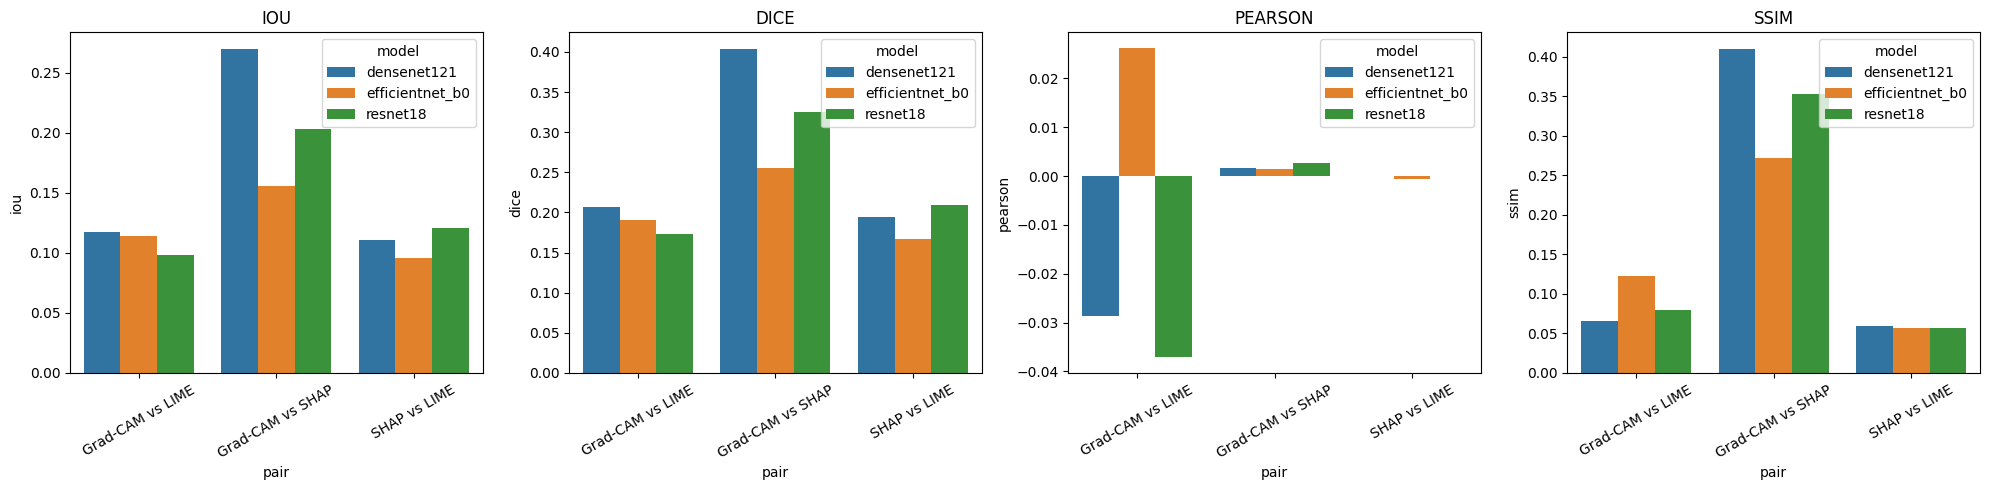

Saved similarity_metrics_barplot.png


In [12]:
def compute_iou(map1, map2, threshold=0.5):
    mask1, mask2 = map1 >= threshold, map2 >= threshold
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0

def compute_dice(map1, map2, threshold=0.5):
    mask1, mask2 = map1 >= threshold, map2 >= threshold
    intersection = np.logical_and(mask1, mask2).sum()
    denom = mask1.sum() + mask2.sum()
    return (2 * intersection) / denom if denom > 0 else 0.0

def compute_pearson(map1, map2):
    return pearsonr(map1.flatten(), map2.flatten())[0]

def compute_ssim(map1, map2):
    return ssim(map1, map2, data_range=float(map2.max() - map2.min()) + 1e-8)

similarity_results = []
for model_name in model_names:
    for img_idx in explanation_maps[model_name]:
        maps = explanation_maps[model_name][img_idx]
        gradcam = resize(maps["gradcam"], (224, 224))
        shap_map = resize(maps["shap"], (224, 224))
        lime_map = resize(maps["lime"], (224, 224))
        pairs = {
            "Grad-CAM vs SHAP": (gradcam, shap_map),
            "Grad-CAM vs LIME": (gradcam, lime_map),
            "SHAP vs LIME": (shap_map, lime_map),
        }
        for pair_name, (m1, m2) in pairs.items():
            similarity_results.append({
                "model": model_name, "image_idx": img_idx, "pair": pair_name,
                "iou": compute_iou(m1, m2), "dice": compute_dice(m1, m2),
                "pearson": compute_pearson(m1, m2), "ssim": compute_ssim(m1, m2)
            })

similarity_df = pd.DataFrame(similarity_results)
similarity_df.to_csv("/kaggle/working/similarity_metrics.csv", index=False)
similarity_summary = similarity_df.groupby(["model", "pair"])[["iou", "dice", "pearson", "ssim"]].mean()
print(similarity_summary)

similarity_summary_reset = similarity_summary.reset_index()
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, metric in enumerate(["iou", "dice", "pearson", "ssim"]):
    sns.barplot(data=similarity_summary_reset, x="pair", y=metric, hue="model", ax=axes[i])
    axes[i].set_title(metric.upper())
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig("/kaggle/working/similarity_metrics_barplot.png")
plt.show()   # <-- CHANGED: was plt.close()
print("Saved similarity_metrics_barplot.png")

                         insertion_auc  deletion_auc  average_drop  \
model           method                                               
densenet121     gradcam       0.656199      0.386130      0.344049   
                lime          0.501792      0.508278      0.673617   
                shap          0.418912      0.369997      0.530763   
efficientnet_b0 gradcam       0.506595      0.338600      0.496250   
                lime          0.439440      0.388019      0.615049   
                shap          0.369365      0.351643      0.887999   
resnet18        gradcam       0.803235      0.557662      0.380697   
                lime          0.678470      0.595095      0.839344   
                shap          0.327234      0.259833      0.793630   

                         increase_in_confidence  
model           method                           
densenet121     gradcam                    0.10  
                lime                       0.05  
                shap         

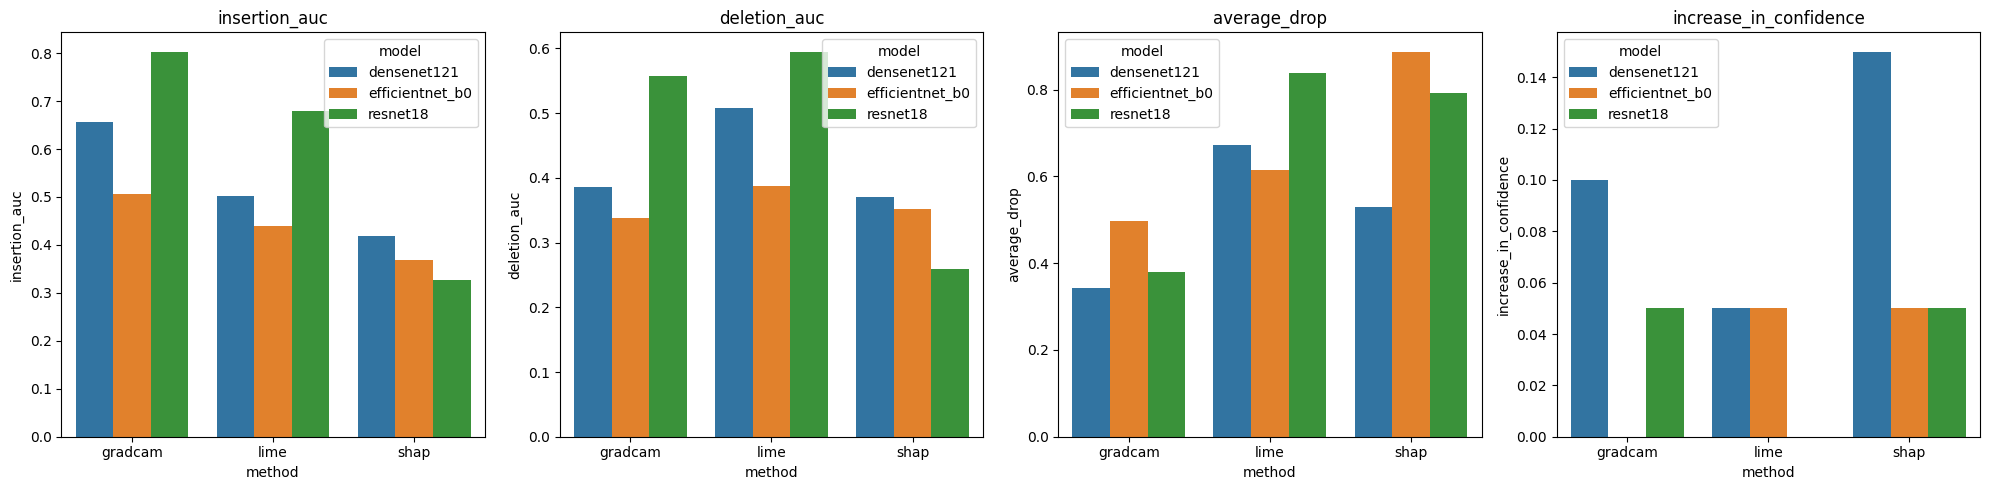

Saved faithfulness_metrics_barplot.png


In [13]:
def get_confidence(model, image_tensor, target_class):
    model.eval()
    with torch.no_grad():
        output = model(image_tensor.unsqueeze(0).to(device))
        prob = F.softmax(output, dim=1)
    return prob[0, target_class].item()


def insertion_deletion(model, image_tensor, saliency_map, target_class, steps=10):
    saliency_resized = resize(saliency_map, (224, 224))
    saliency_flat = saliency_resized.flatten()
    order = np.argsort(-saliency_flat)
    total_pixels = len(order)

    blurred = F.avg_pool2d(image_tensor.unsqueeze(0), kernel_size=11, stride=1, padding=5).squeeze(0)

    insertion_scores, deletion_scores = [], []
    for step in range(steps + 1):
        num_pixels = int((step / steps) * total_pixels)
        mask_flat = np.zeros(total_pixels, dtype=bool)
        mask_flat[order[:num_pixels]] = True
        mask = torch.tensor(mask_flat.reshape(224, 224), dtype=torch.bool)

        inserted_image = blurred.clone()
        for c in range(3):
            inserted_image[c][mask] = image_tensor[c][mask]
        insertion_scores.append(get_confidence(model, inserted_image, target_class))

        deleted_image = image_tensor.clone()
        for c in range(3):
            deleted_image[c][mask] = blurred[c][mask]
        deletion_scores.append(get_confidence(model, deleted_image, target_class))

    insertion_auc = np.trapezoid(insertion_scores, dx=1 / steps)
    deletion_auc = np.trapezoid(deletion_scores, dx=1 / steps)
    return insertion_auc, deletion_auc


def average_drop_and_increase(model, image_tensor, saliency_map, target_class, threshold=0.5):
    original_confidence = get_confidence(model, image_tensor, target_class)
    saliency_resized = resize(saliency_map, (224, 224))
    mask = saliency_resized >= threshold
    mask_tensor = torch.tensor(mask, dtype=torch.float32)

    masked_image = image_tensor.clone()
    for c in range(3):
        masked_image[c] = image_tensor[c] * mask_tensor

    masked_confidence = get_confidence(model, masked_image, target_class)
    drop = max(0, original_confidence - masked_confidence) / original_confidence if original_confidence > 0 else 0
    increase = 1 if masked_confidence > original_confidence else 0
    return drop, increase


faithfulness_results = []
for model_name in model_names:
    model = models_dict[model_name]
    for img_idx in explanation_maps[model_name]:
        image_tensor = all_test_images[img_idx]
        target_class = all_test_labels[img_idx].item()
        maps = explanation_maps[model_name][img_idx]

        for method_name in ["gradcam", "shap", "lime"]:
            saliency_map = maps[method_name]
            ins_auc, del_auc = insertion_deletion(model, image_tensor, saliency_map, target_class)
            drop, increase = average_drop_and_increase(model, image_tensor, saliency_map, target_class)
            faithfulness_results.append({
                "model": model_name, "method": method_name, "image_idx": img_idx,
                "insertion_auc": ins_auc, "deletion_auc": del_auc,
                "average_drop": drop, "increase_in_confidence": increase
            })

faithfulness_df = pd.DataFrame(faithfulness_results)
faithfulness_df.to_csv("/kaggle/working/faithfulness_metrics.csv", index=False)
faithfulness_summary = faithfulness_df.groupby(["model", "method"])[
    ["insertion_auc", "deletion_auc", "average_drop", "increase_in_confidence"]
].mean()
print(faithfulness_summary)

faithfulness_summary_reset = faithfulness_summary.reset_index()
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, metric in enumerate(["insertion_auc", "deletion_auc", "average_drop", "increase_in_confidence"]):
    sns.barplot(data=faithfulness_summary_reset, x="method", y=metric, hue="model", ax=axes[i])
    axes[i].set_title(metric)
plt.tight_layout()
plt.savefig("/kaggle/working/faithfulness_metrics_barplot.png")
plt.show()   # <-- CHANGED: was plt.close()
print("Saved faithfulness_metrics_barplot.png")